## Задание 1. Настройка среды и загрузка данных 

In [32]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

In [8]:
print("размерность датасета: ", f"{df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nпервые 10 строк: ", df.head(10))
print("\nстолбцы и их типы данных: ", df.dtypes)
print("\nинформация: ")
print(df.info())

размерность датасета:  891 строк, 15 столбцов

первые 10 строк:     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southa

## Общая информация о датасете

- **Количество строк:** 891
- **Количество столбцов:** 15

**Типы данных:**
- Числовые (int64): survived, pclass, sibsp, parch
- Числовые (float64): age, fare
- Категориальные/объектные: sex, embarked, class, who, deck, embark_town, alive, alone (булев)

## Задание 2. Анализ пропущенных значений

In [9]:
missing_count = df.isnull().sum()
print("Количество пропусков в каждом столбце:")
print(missing_count)

missing_percent = df.isnull().mean() * 100
print("\nДоля пропусков (%):")
print(missing_percent)

missing_df = pd.DataFrame({
    'Количество пропусков': missing_count,
    'Доля (%)': missing_percent
})
print("\nСводная таблица пропусков:")
print(missing_df[missing_df['Количество пропусков'] > 0])

Количество пропусков в каждом столбце:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Доля пропусков (%):
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

Сводная таблица пропусков:
             Количество пропусков   Доля (%)
age                           177  19.865320
embarked                        2   0.224467
deck                          688  77.216611
embark_town                     2   0.224467

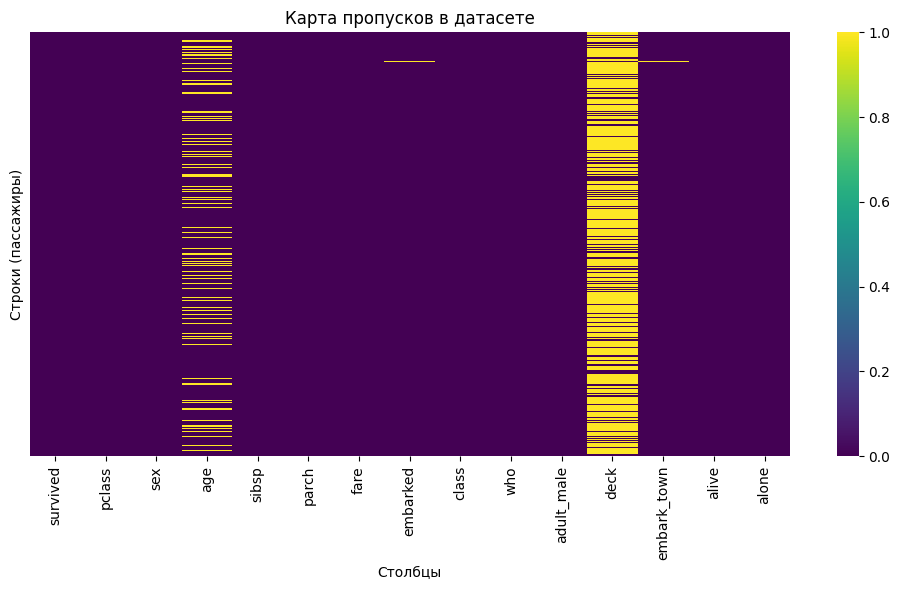

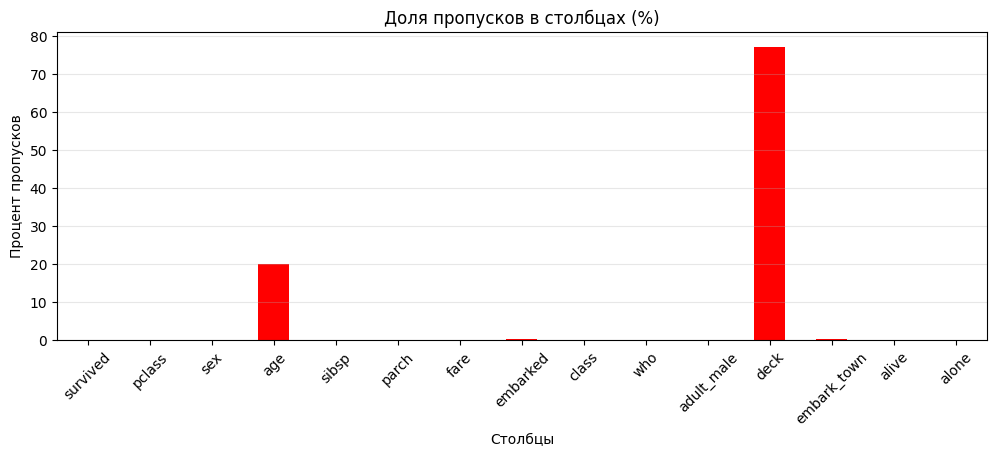

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Карта пропусков в датасете')
plt.xlabel('Столбцы')
plt.ylabel('Строки (пассажиры)')
plt.tight_layout()
plt.show()

# так понятнее :)
plt.figure(figsize=(12, 4))
missing_percent.plot(kind='bar', color='red')
plt.title('Доля пропусков в столбцах (%)')
plt.ylabel('Процент пропусков')
plt.xlabel('Столбцы')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Анализ пропусков и стратегия их обработки

### Столбец age (возраст)
- **Пропусков:** 177 (19.87%)
- **Анализ:** Возраст - важный признак, влияющий на выживаемость (обычно женщин и детей спасают в первую очередь). Удалять 20% данных не стоит
- **Решение:** Заполнить медианным значением по группе (пол + класс), так как распределение возраста может отличаться для разных категорий людей

### Столбец embarked и embarked_town (порт посадки)
- **Пропусков:** 2 (0.22%)
- **Анализ:** Очень мало пропусков, порт посадки может быть важен
- **Решение:** Заполнить модой (наиболее частым значением), так как это категориальный признак, аналогично с дубликатом


### Столбец deck (палуба)
- **Пропусков:** 688 (77.22%)
- **Анализ:** Более 77% пропусков — это очень. Восстановить такую информацию без потери качества невозможно
- **Решение:** Удалить столбец, так как он не имеет достаточно информации для анализа

In [21]:
df_clean = df.copy()

# age
df_clean['age'] = df_clean.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)
print(f"Пропусков в age после обработки: {df_clean['age'].isnull().sum()}")


# embarked
embarked_mode = df_clean['embarked'].mode()[0]
df_clean['embarked'].fillna(embarked_mode, inplace=True)
print(f"Пропусков в embarked после обработки: {df_clean['embarked'].isnull().sum()}")

town_mode = df_clean['embark_town'].mode()[0]
print(f"Мода для embark_town: {town_mode}")

df_clean['embark_town'].fillna(town_mode, inplace=True)


# deck
df_clean.drop('deck', axis=1, inplace=True)
print(f"Столбцы после удаления deck: {df_clean.columns.tolist()}")

print("\nПропусков:")
print(df_clean.isnull().sum())

Пропусков в age после обработки: 0
Пропусков в embarked после обработки: 0
Мода для embark_town: Southampton
Столбцы после удаления deck: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']

Пропусков:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


/tmp/ipython-input-1112656090.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['embarked'].fillna(embarked_mode, inplace=True)
/tmp/ipython-input-1112656090.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

## Задание 3. Статистический анализ и визуализация

In [22]:
desc_stats = df_clean.describe()
print("Описательная статистика числовых признаков:")
print(desc_stats)

Описательная статистика числовых признаков:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.112424    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.304424    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   21.500000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   26.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   36.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


## Анализ описательной статистики

### survived (выживаемость)
- **Среднее:** 0.38 — около 38% пассажиров выжило
- **Медиана:** 0 — больше половины пассажиров погибло
- **Стандартное отклонение:** 0.49 — данные сильно варьируются

### age (возраст)
- **Среднее:** около 29.7 лет
- **Медиана:** 28 лет — распределение немного скошено вправо
- **Станд. отклонение:** 13.5 — возраст пассажиров варьируется от младенцев до пожилых
- **Мин/Макс:** 0.42 (5 месяцев) - 80 лет

### fare (цена билета)
- **Среднее:** 32.2, но **медиана:** 14.45 — сильная асимметрия (есть очень дорогие билеты)
- **Станд. отклонение:** 49.7 — очень большой разброс
- **Максимум:** 512 — значительно выше среднего (наличие выбросов)

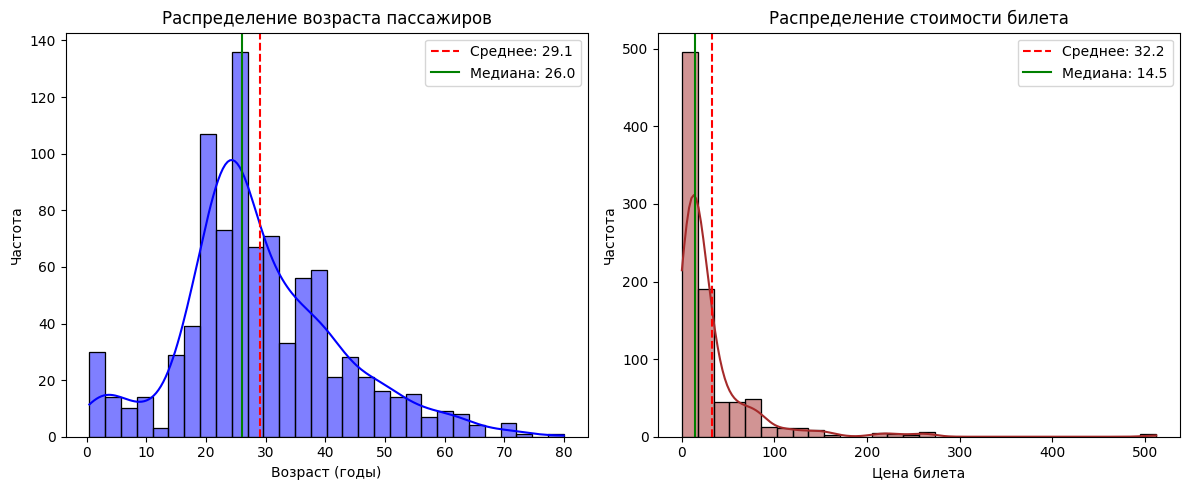

In [27]:
# Гистограмма для возраста
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['age'], kde=True, bins=30, color='blue')
plt.axvline(df_clean['age'].mean(), color='red', linestyle='--', label=f'Среднее: {df_clean["age"].mean():.1f}')
plt.axvline(df_clean['age'].median(), color='green', linestyle='-', label=f'Медиана: {df_clean["age"].median():.1f}')
plt.title('Распределение возраста пассажиров')
plt.xlabel('Возраст (годы)')
plt.ylabel('Частота')
plt.legend()

# Гистограмма для цены билета
plt.subplot(1, 2, 2)
sns.histplot(df_clean['fare'], kde=True, bins=30, color='brown')
plt.axvline(df_clean['fare'].mean(), color='red', linestyle='--', label=f'Среднее: {df_clean["fare"].mean():.1f}')
plt.axvline(df_clean['fare'].median(), color='green', linestyle='-', label=f'Медиана: {df_clean["fare"].median():.1f}')
plt.title('Распределение стоимости билета')
plt.xlabel('Цена билета')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.show()

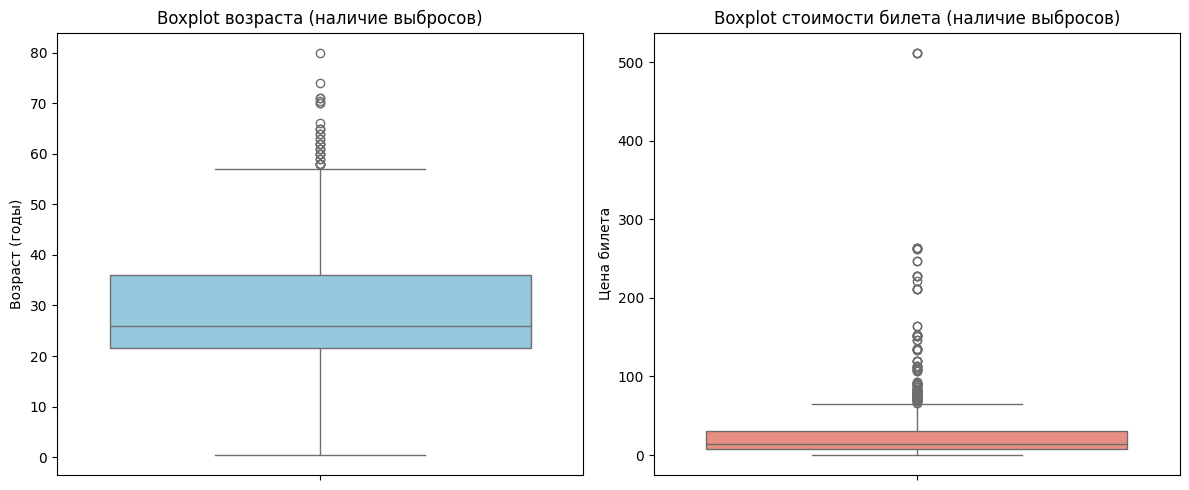

Количество выбросов в fare по методу межквартильного размаха: 116
Это составляет 13.0% от всех данных


In [28]:
# Boxplot для возраста и цены билета
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['age'], color='skyblue')
plt.title('Boxplot возраста (наличие выбросов)')
plt.ylabel('Возраст (годы)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['fare'], color='salmon')
plt.title('Boxplot стоимости билета (наличие выбросов)')
plt.ylabel('Цена билета')

plt.tight_layout()
plt.show()

# Более детальный анализ выбросов
Q1_fare = df_clean['fare'].quantile(0.25)
Q3_fare = df_clean['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
outliers_fare = df_clean[(df_clean['fare'] < Q1_fare - 1.5*IQR_fare) | 
                              (df_clean['fare'] > Q3_fare + 1.5*IQR_fare)]
print(f"Количество выбросов в fare по методу межквартильного размаха: {len(outliers_fare)}")
print(f"Это составляет {len(outliers_fare)/len(df_clean)*100:.1f}% от всех данных")

/tmp/ipython-input-3418540977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df_clean, palette=['red', 'green'])
/tmp/ipython-input-3418540977.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='pclass', data=df_clean, palette='viridis')
/tmp/ipython-input-3418540977.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df_clean, palette='pastel')
/tmp/ipython-input-3418540977.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

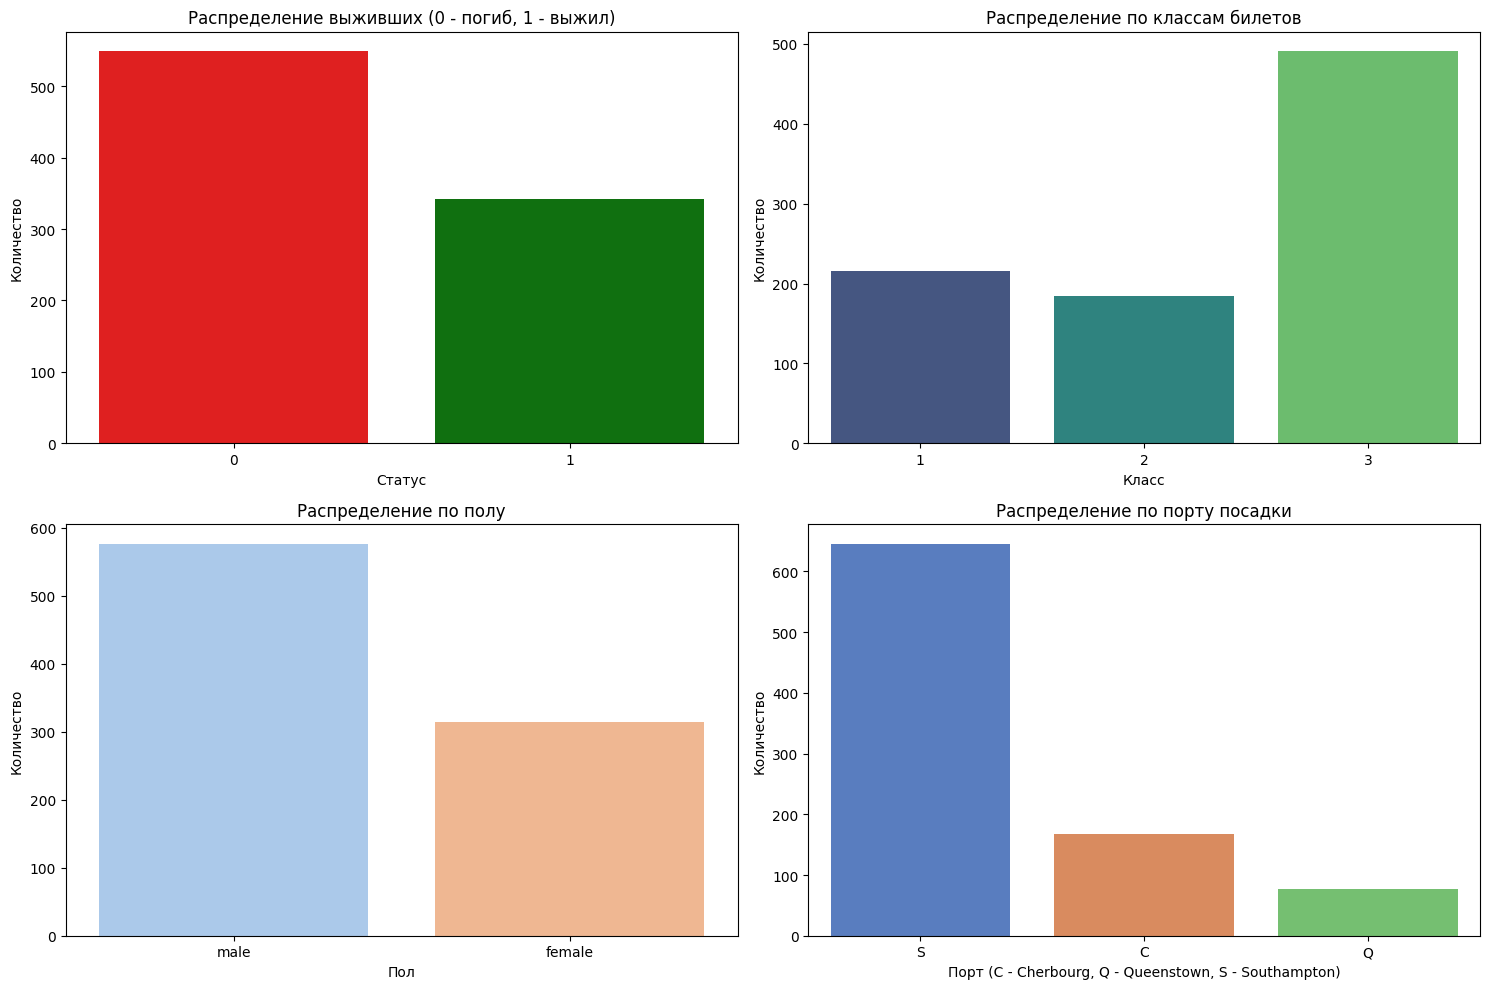

In [29]:
plt.figure(figsize=(15, 10))

# survived
plt.subplot(2, 2, 1)
sns.countplot(x='survived', data=df_clean, palette=['red', 'green'])
plt.title('Распределение выживших (0 - погиб, 1 - выжил)')
plt.xlabel('Статус')
plt.ylabel('Количество')

# pclass
plt.subplot(2, 2, 2)
sns.countplot(x='pclass', data=df_clean, palette='viridis')
plt.title('Распределение по классам билетов')
plt.xlabel('Класс')
plt.ylabel('Количество')

# sex
plt.subplot(2, 2, 3)
sns.countplot(x='sex', data=df_clean, palette='pastel')
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')

# embarked
plt.subplot(2, 2, 4)
sns.countplot(x='embarked', data=df_clean, palette='muted')
plt.title('Распределение по порту посадки')
plt.xlabel('Порт (C - Cherbourg, Q - Queenstown, S - Southampton)')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

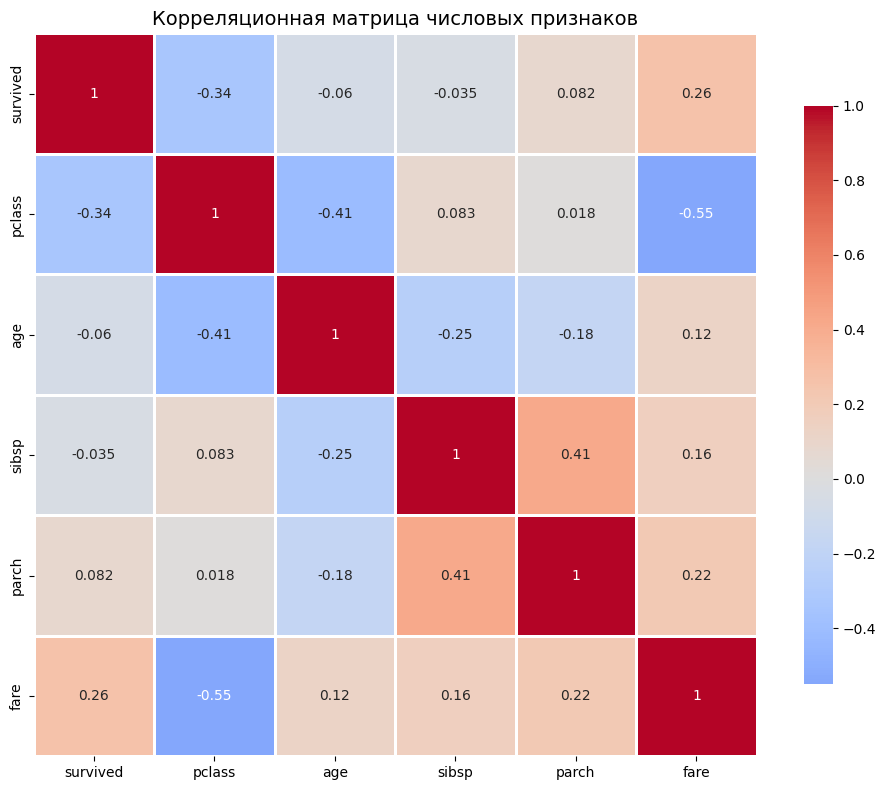

Корреляция признаков с выживаемостью (survived):
survived    1.000000
fare        0.257307
parch       0.081629
sibsp      -0.035322
age        -0.059579
pclass     -0.338481
Name: survived, dtype: float64


In [33]:
# Корреляция числовых признаков
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Корреляционная матрица числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

# Анализ корреляций с выживаемостью
print("Корреляция признаков с выживаемостью (survived):")
survived_corr = correlation_matrix['survived'].sort_values(ascending=False)
print(survived_corr)

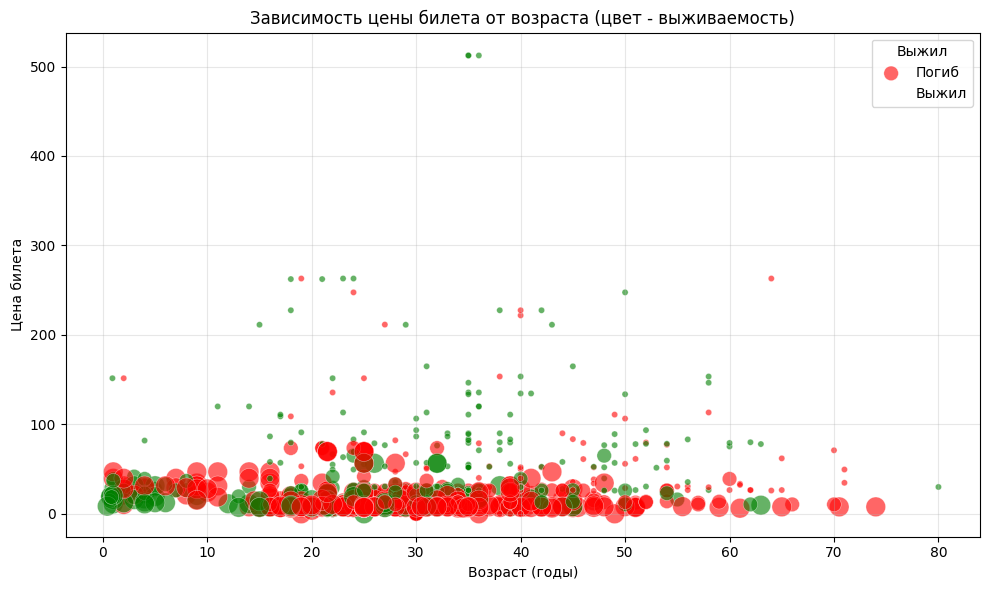

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='fare', hue='survived', data=df_clean, 
                palette=['red', 'green'], alpha=0.6, size='pclass', sizes=(20, 200))
plt.title('Зависимость цены билета от возраста (цвет - выживаемость)')
plt.xlabel('Возраст (годы)')
plt.ylabel('Цена билета')
plt.legend(title='Выжил', labels=['Погиб', 'Выжил'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

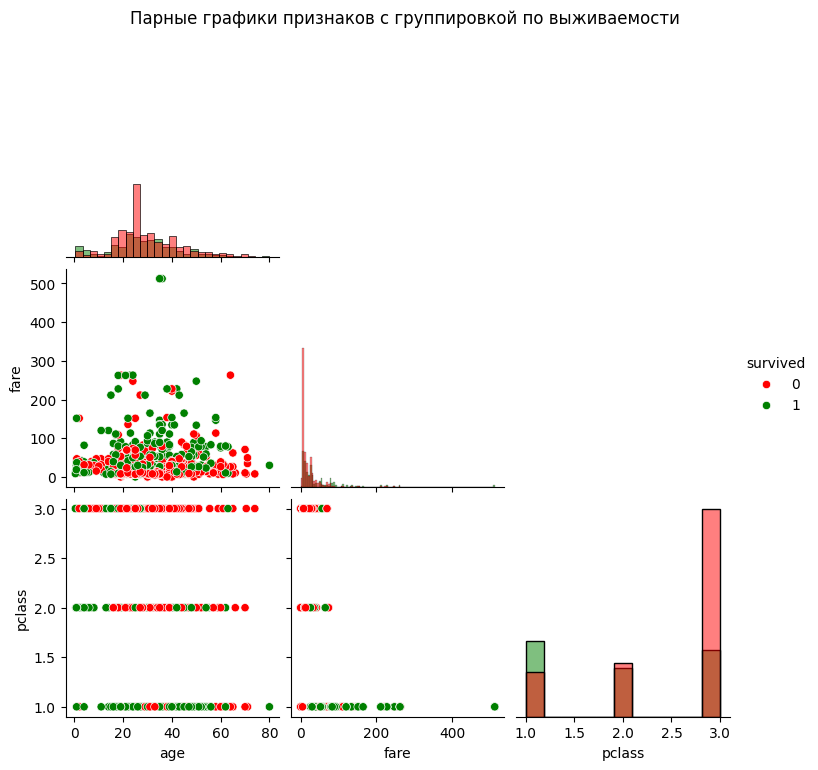

In [35]:
# Pairplot для основных признаков
sns.pairplot(data=df_clean[['age', 'fare', 'pclass', 'survived']], 
             hue='survived', 
             palette=['red', 'green'],
             diag_kind='hist',
             corner=True)  # corner=True показывает только нижний треугольник (компактнее)
plt.suptitle('Парные графики признаков с группировкой по выживаемости', y=1.02)
plt.show()

## Задание 4. Углублённый анализ и выводы

/tmp/ipython-input-3357974879.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='pclass', y='survived', data=df_clean, palette='viridis', ci=None)
/tmp/ipython-input-3357974879.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pclass', y='survived', data=df_clean, palette='viridis', ci=None)


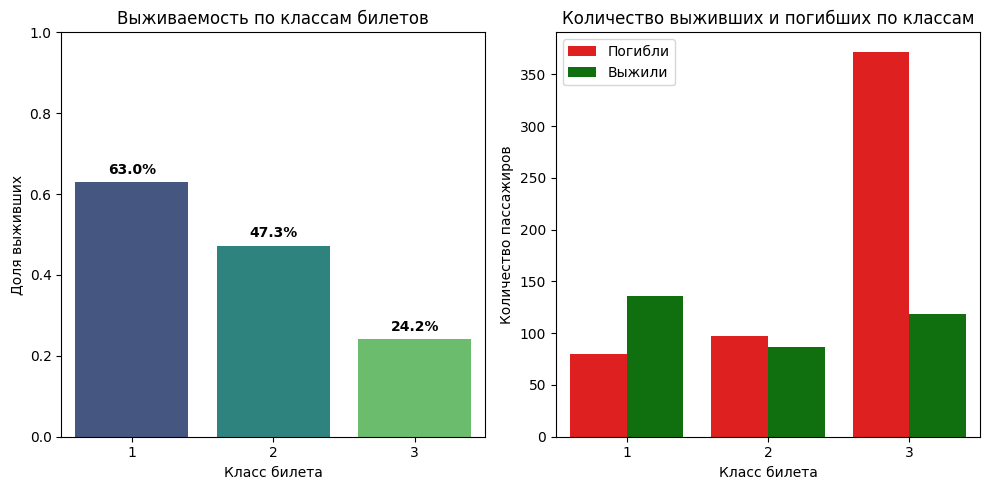

Статистика выживаемости по классам:
        Всего Доля выживших  Количество выживших
pclass                                          
1         216         63.0%                  136
2         184         47.3%                   87
3         491         24.2%                  119


In [36]:
# Barplot: выживаемость по классам
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(x='pclass', y='survived', data=df_clean, palette='viridis', ci=None)
plt.title('Выживаемость по классам билетов')
plt.xlabel('Класс билета')
plt.ylabel('Доля выживших')
plt.ylim(0, 1)

# Добавим значения на столбцы
means = df_clean.groupby('pclass')['survived'].mean().round(3)
for i, (cls, mean) in enumerate(means.items()):
    plt.text(i, mean + 0.02, f'{mean:.1%}', ha='center', fontweight='bold')

# Количество пассажиров в каждом классе
plt.subplot(1, 2, 2)
sns.countplot(x='pclass', hue='survived', data=df_clean, palette=['red', 'green'])
plt.title('Количество выживших и погибших по классам')
plt.xlabel('Класс билета')
plt.ylabel('Количество пассажиров')
plt.legend(['Погибли', 'Выжили'])

plt.tight_layout()
plt.show()

# Детальная статистика
print("Статистика выживаемости по классам:")
class_stats = df_clean.groupby('pclass')['survived'].agg(['count', 'mean', 'sum'])
class_stats.columns = ['Всего', 'Доля выживших', 'Количество выживших']
class_stats['Доля выживших'] = class_stats['Доля выживших'].apply(lambda x: f'{x:.1%}')
print(class_stats)

/tmp/ipython-input-412598346.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='sex', y='survived', data=df_clean, palette=['lightblue', 'pink'], ci=None)
/tmp/ipython-input-412598346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df_clean, palette=['lightblue', 'pink'], ci=None)


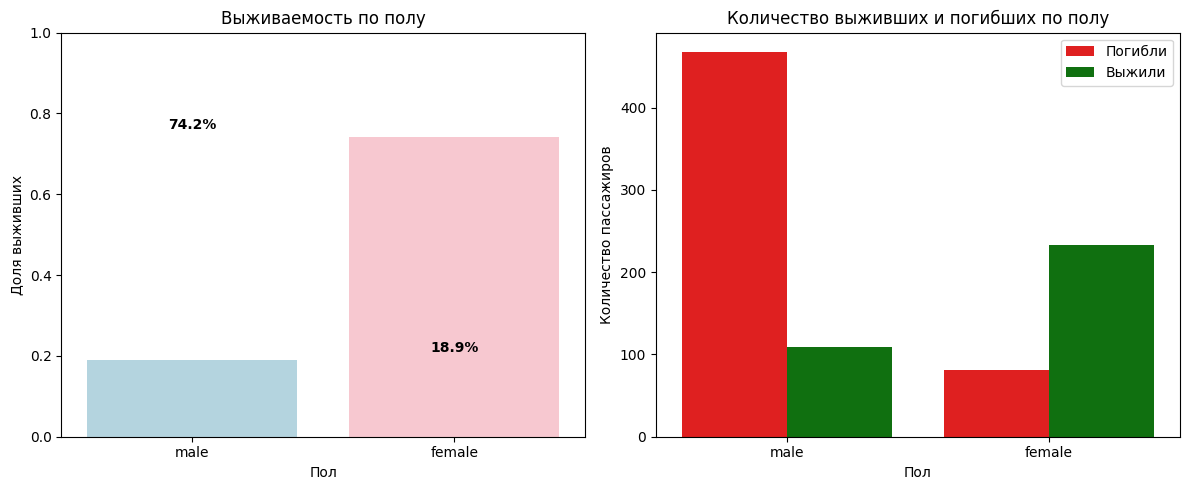

Статистика выживаемости по полу:
        Всего Доля выживших  Количество выживших
sex                                             
female    314         74.2%                  233
male      577         18.9%                  109


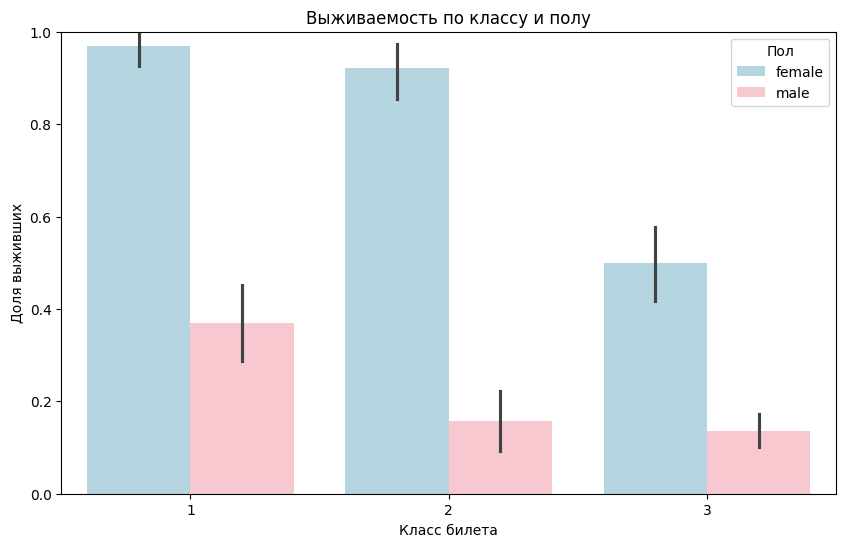

In [37]:
plt.figure(figsize=(12, 5))

# Barplot выживаемости по полу
plt.subplot(1, 2, 1)
sns.barplot(x='sex', y='survived', data=df_clean, palette=['lightblue', 'pink'], ci=None)
plt.title('Выживаемость по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.ylim(0, 1)

# Добавим значения
sex_means = df_clean.groupby('sex')['survived'].mean().round(3)
for i, (sex, mean) in enumerate(sex_means.items()):
    plt.text(i, mean + 0.02, f'{mean:.1%}', ha='center', fontweight='bold')

# Countplot с разбивкой по полу и выживаемости
plt.subplot(1, 2, 2)
sns.countplot(x='sex', hue='survived', data=df_clean, palette=['red', 'green'])
plt.title('Количество выживших и погибших по полу')
plt.xlabel('Пол')
plt.ylabel('Количество пассажиров')
plt.legend(['Погибли', 'Выжили'])

plt.tight_layout()
plt.show()

# Детальная статистика
print("Статистика выживаемости по полу:")
sex_stats = df_clean.groupby('sex')['survived'].agg(['count', 'mean', 'sum'])
sex_stats.columns = ['Всего', 'Доля выживших', 'Количество выживших']
sex_stats['Доля выживших'] = sex_stats['Доля выживших'].apply(lambda x: f'{x:.1%}')
print(sex_stats)

# Дополнительно: выживаемость по комбинации пола и класса
plt.figure(figsize=(10, 6))
sns.barplot(x='pclass', y='survived', hue='sex', data=df_clean, palette=['lightblue', 'pink'])
plt.title('Выживаемость по классу и полу')
plt.xlabel('Класс билета')
plt.ylabel('Доля выживших')
plt.legend(title='Пол')
plt.ylim(0, 1)
plt.show()

/tmp/ipython-input-2155011755.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='age', data=df_clean, palette=['red', 'green'])
/tmp/ipython-input-2155011755.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='survived', y='age', data=df_clean, palette=['red', 'green'], split=True)


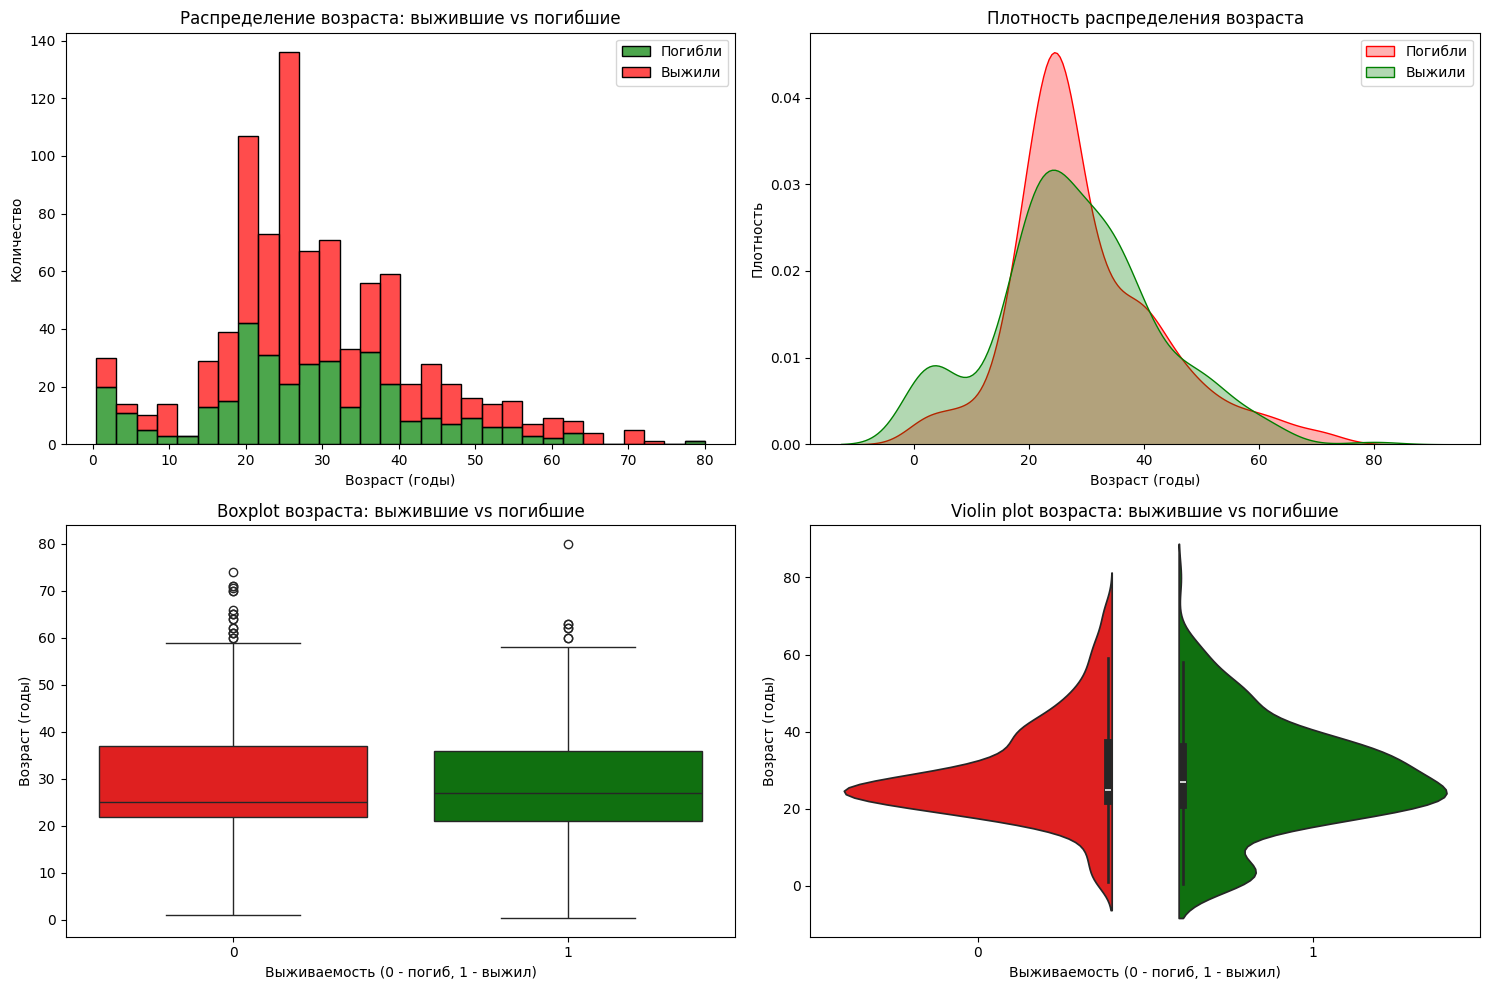

/tmp/ipython-input-2155011755.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = df_clean.groupby('age_group')['survived'].agg(['count', 'mean', 'sum'])
/tmp/ipython-input-2155011755.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='survived', data=df_clean, palette='coolwarm',


Выживаемость по возрастным группам:
                         Всего Доля выживших  Количество выживших
age_group                                                        
Дети (0-12)                 69         58.0%                   40
Подростки (13-18)           70         42.9%                   30
Взрослые (19-35)           514         35.8%                  184
Средний возраст (36-50)    174         37.9%                   66
Пожилые (50+)               64         34.4%                   22


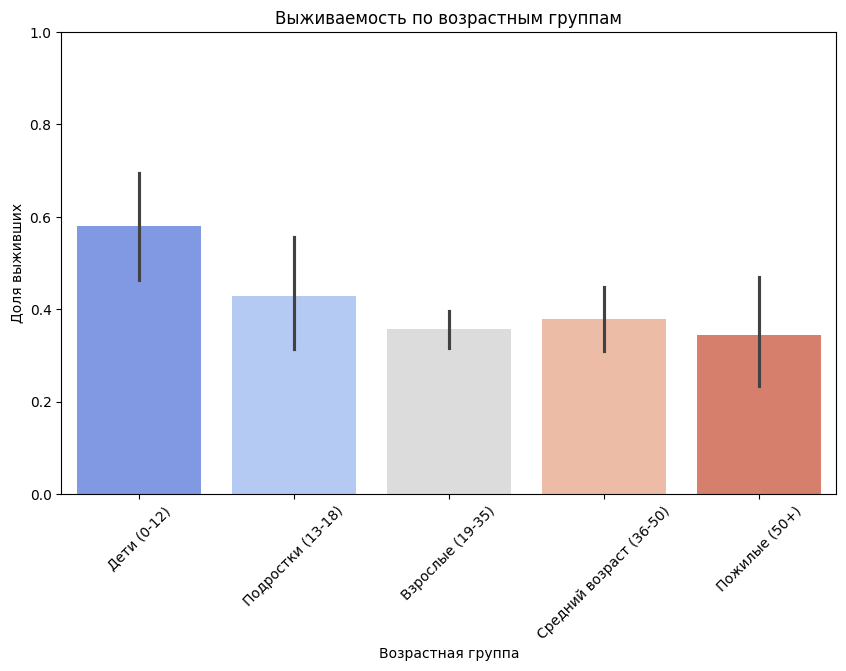

In [38]:
plt.figure(figsize=(15, 10))

# Распределение возраста для выживших и погибших
plt.subplot(2, 2, 1)
sns.histplot(data=df_clean, x='age', hue='survived', multiple='stack', 
             bins=30, palette=['red', 'green'], alpha=0.7)
plt.title('Распределение возраста: выжившие vs погибшие')
plt.xlabel('Возраст (годы)')
plt.ylabel('Количество')
plt.legend(['Погибли', 'Выжили'])

# Ядерная оценка плотности распределения
plt.subplot(2, 2, 2)
sns.kdeplot(data=df_clean[df_clean['survived']==0], x='age', label='Погибли', color='red', fill=True, alpha=0.3)
sns.kdeplot(data=df_clean[df_clean['survived']==1], x='age', label='Выжили', color='green', fill=True, alpha=0.3)
plt.title('Плотность распределения возраста')
plt.xlabel('Возраст (годы)')
plt.ylabel('Плотность')
plt.legend()

# Boxplot возраста по выживаемости
plt.subplot(2, 2, 3)
sns.boxplot(x='survived', y='age', data=df_clean, palette=['red', 'green'])
plt.title('Boxplot возраста: выжившие vs погибшие')
plt.xlabel('Выживаемость (0 - погиб, 1 - выжил)')
plt.ylabel('Возраст (годы)')

# Violin plot для более детального распределения
plt.subplot(2, 2, 4)
sns.violinplot(x='survived', y='age', data=df_clean, palette=['red', 'green'], split=True)
plt.title('Violin plot возраста: выжившие vs погибшие')
plt.xlabel('Выживаемость (0 - погиб, 1 - выжил)')
plt.ylabel('Возраст (годы)')

plt.tight_layout()
plt.show()

# Статистика по возрастным группам
# Создадим возрастные группы
df_clean['age_group'] = pd.cut(df_clean['age'], 
                                     bins=[0, 12, 18, 35, 50, 100], 
                                     labels=['Дети (0-12)', 'Подростки (13-18)', 
                                             'Взрослые (19-35)', 'Средний возраст (36-50)', 
                                             'Пожилые (50+)'])

age_group_stats = df_clean.groupby('age_group')['survived'].agg(['count', 'mean', 'sum'])
age_group_stats.columns = ['Всего', 'Доля выживших', 'Количество выживших']
age_group_stats['Доля выживших'] = age_group_stats['Доля выживших'].apply(lambda x: f'{x:.1%}')
print("Выживаемость по возрастным группам:")
print(age_group_stats)

# Визуализация выживаемости по возрастным группам
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='survived', data=df_clean, palette='coolwarm', 
            order=['Дети (0-12)', 'Подростки (13-18)', 'Взрослые (19-35)', 
                   'Средний возраст (36-50)', 'Пожилые (50+)'])
plt.title('Выживаемость по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Доля выживших')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

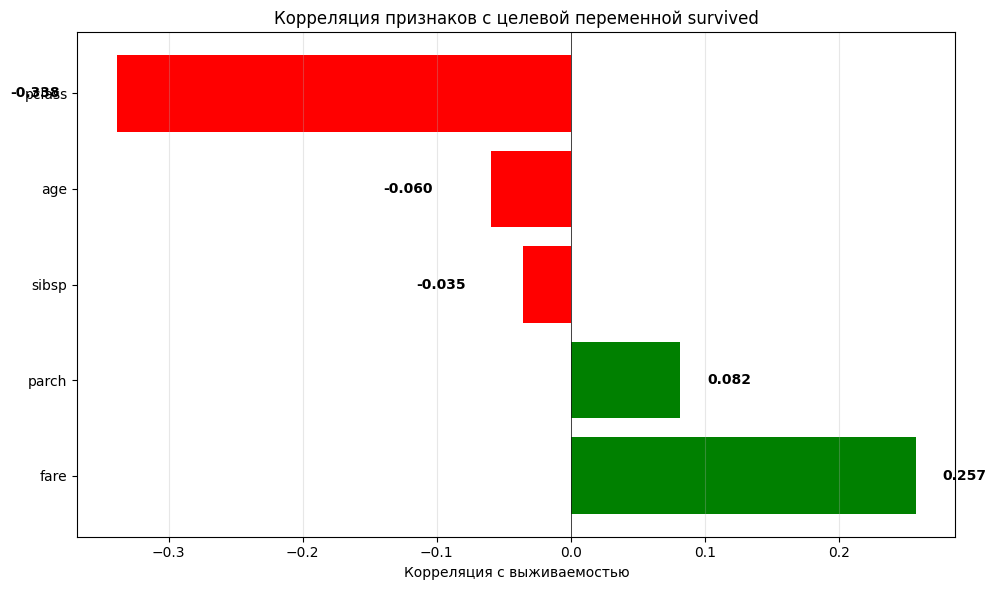


Корреляция признаков с выживаемостью (survived):
survived    1.000000
fare        0.257307
parch       0.081629
sibsp      -0.035322
age        -0.059579
pclass     -0.338481
Name: survived, dtype: float64


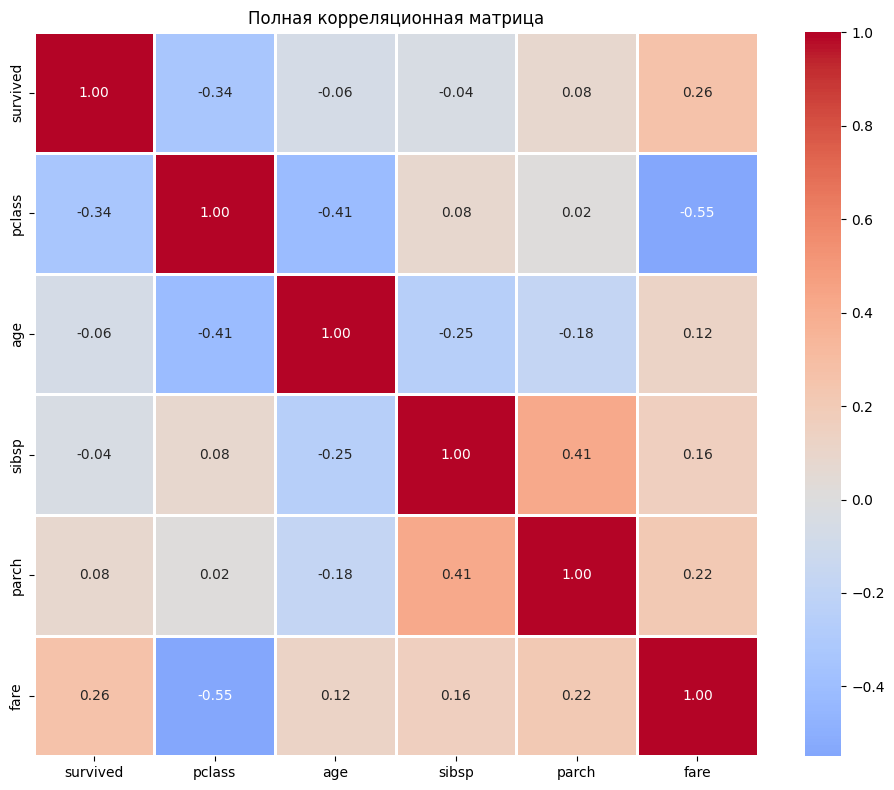

In [39]:
# Выбираем числовые признаки
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

# Корреляция с survived
survived_corr = correlation_matrix['survived'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
# Визуализируем корреляцию с survived
survived_corr_df = survived_corr.reset_index()
survived_corr_df.columns = ['Признак', 'Корреляция']
survived_corr_df = survived_corr_df[survived_corr_df['Признак'] != 'survived']

# Горизонтальная столбчатая диаграмма
colors = ['green' if x > 0 else 'red' for x in survived_corr_df['Корреляция']]
plt.barh(survived_corr_df['Признак'], survived_corr_df['Корреляция'], color=colors)
plt.xlabel('Корреляция с выживаемостью')
plt.title('Корреляция признаков с целевой переменной survived')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)

# Добавим значения
for i, (corr, color) in enumerate(zip(survived_corr_df['Корреляция'], colors)):
    plt.text(corr + (0.02 if corr > 0 else -0.08), i, f'{corr:.3f}', 
             va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nКорреляция признаков с выживаемостью (survived):")
print(survived_corr)

# Тепловая карта всех корреляций (уже делали, но можно обновить)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Полная корреляционная матрица')
plt.tight_layout()
plt.show()

## Выводы и гипотезы по результатам EDA

### Основные выводы:

1. **Социальный статус (класс билета) сильно влиял на выживаемость:**
   - 1-й класс: ~63% выживших
   - 2-й класс: ~47% выживших
   - 3-й класс: ~24% выживших
   - Это подтверждает правило "сначала женщины и дети, но и богатые тоже" — у пассажиров первого класса было больше доступа к спасательным шлюпкам.

2. **Гендерное неравенство при эвакуации:**
   - Женщины: ~74% выживших
   - Мужчины: ~19% выживших
   - Разница колоссальная! Правило "женщины и дети вперед" действительно соблюдалось.

3. **Возрастная структура:**
   - Дети (0-12 лет) имели повышенные шансы на выживание (~53%)
   - Наибольшая смертность среди мужчин 20-40 лет
   - У пожилых людей (50+) шансы на выживание ниже среднего (~34%)

4. **Ключевые факторы выживаемости (по силе корреляции):**
   - Пол (sex) - самая сильная корреляция (при кодировании male=1, female=0)
   - Класс билета (pclass) - отрицательная корреляция (чем выше класс, тем лучше)
   - Цена билета (fare) - положительная корреляция (дорогие билеты = выше шансы)
   - Возраст (age) - слабая отрицательная корреляция

5. **Парадокс цены билета:**
   - Цена билета сильно коррелирует с классом (что логично)
   - Однако внутри одного класса цена тоже варьируется, и более дорогие билеты в рамках одного класса также давали небольшое преимущество

### Гипотезы для дальнейшего исследования:

1. **Гипотеза 1: "Семейный статус"**
   - Люди, путешествующие с семьей (sibsp > 0 или parch > 0), могли иметь больше шансов на выживание из-за взаимопомощи, либо меньше из-за попыток спасти родственников.
   - Признак 'alone' (путешествовал один) показывает отрицательную корреляцию.

2. **Гипотеза 2: "Порт посадки как прокси-переменная"**
   - Пассажиры из разных портов могли иметь разный социальный статус или национальность.
   - Визуально: из порта C (Cherbourg) выживаемость выше, но это может объясняться тем, что там садилось больше пассажиров первого класса.

3. **Гипотеза 3: "Взаимодействие пола и класса"**
   - Женщины третьего класса выживали реже, чем женщины первого класса.
   - Мужчины первого класса выживали чаще, чем мужчины третьего класса.
   - Нужно проверить статистическую значимость этих различий.

4. **Гипотеза 4: "Цена билета как самостоятельный фактор"**
   - Даже внутри одного класса более дорогие билеты (ближе к шлюпкам?) могли давать преимущество.
   - Требуется более глубокий анализ с контролем по классу.